# Task 1 — Preprocessing

Da tre TSV a livello azione a `../data/manuale.csv` (12 studenti) e `../data/training.csv` (7.035).
Motivazioni e alternative: `documentation/01_preprocessing.md`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CARTELLA = "../data/act-mooc/"
COLONNE_FEATURE = ["FEATURE0", "FEATURE1", "FEATURE2", "FEATURE3"]
SEME = 42          # fissato ovunque, cosi' i due file sono riproducibili

## 1. Caricamento dei tre file

In [2]:
azioni    = pd.read_csv(CARTELLA + "mooc_actions.tsv", sep="\t")
feature   = pd.read_csv(CARTELLA + "mooc_action_features.tsv", sep="\t")
etichette = pd.read_csv(CARTELLA + "mooc_action_labels.tsv", sep="\t")

print("azioni   :", azioni.shape,    list(azioni.columns))
print("feature  :", feature.shape,   list(feature.columns))
print("etichette:", etichette.shape, list(etichette.columns))

azioni.head()

azioni   : (411749, 4) ['ACTIONID', 'USERID', 'TARGETID', 'TIMESTAMP']
feature  : (411749, 5) ['ACTIONID', 'FEATURE0', 'FEATURE1', 'FEATURE2', 'FEATURE3']
etichette: (411749, 2) ['ACTIONID', 'LABEL']


,ACTIONID,USERID,TARGETID,TIMESTAMP
0,0,0,0,0.0
1,1,0,1,6.0
2,2,0,2,41.0
3,3,0,1,49.0
4,4,0,2,51.0


### Unire i tre file

Prima di unirli, controlliamo se `ACTIONID` e' davvero utilizzabile come chiave.

In [3]:
for nome, tabella in [("azioni", azioni), ("feature", feature), ("etichette", etichette)]:
    print(f"{nome:9s} righe = {len(tabella):6d}   ACTIONID distinti = {tabella['ACTIONID'].nunique():6d}")

print()
print("ACTIONID identico fra azioni e feature  :", azioni["ACTIONID"].equals(feature["ACTIONID"]))
print("ACTIONID identico fra azioni e etichette:", azioni["ACTIONID"].equals(etichette["ACTIONID"]))
print("righe con ACTIONID discordante          :", (azioni["ACTIONID"].to_numpy() != etichette["ACTIONID"].to_numpy()).sum())

azioni    righe = 411749   ACTIONID distinti = 411749
feature   righe = 411749   ACTIONID distinti = 411749
etichette righe = 411749   ACTIONID distinti = 396633

ACTIONID identico fra azioni e feature  : True
ACTIONID identico fra azioni e etichette: False
righe con ACTIONID discordante          : 15116


**Fregatura.** In `mooc_action_labels.tsv` `ACTIONID` non e' una chiave (396.633 distinti su
411.749). Un `merge` perderebbe 15.116 righe duplicandone altrettante e restituendo **lo stesso
totale**: `len()` non se ne accorge. Uniamo per posizione con `.to_numpy()`.

In [4]:
dati = azioni.copy()
dati[COLONNE_FEATURE] = feature[COLONNE_FEATURE].to_numpy()
dati["LABEL"] = etichette["LABEL"].to_numpy()

print("tabella unica:", dati.shape)
dati.head()

tabella unica: (411749, 9)


,ACTIONID,USERID,TARGETID,TIMESTAMP,FEATURE0,FEATURE1,FEATURE2,FEATURE3,LABEL
0,0,0,0,0.0,-0.319991,-0.435701,0.106784,-0.067309,0
1,1,0,1,6.0,-0.319991,-0.435701,0.106784,-0.067309,0
2,2,0,2,41.0,-0.319991,-0.435701,0.106784,-0.067309,0
3,3,0,1,49.0,-0.319991,-0.435701,0.106784,-0.067309,0
4,4,0,2,51.0,-0.319991,-0.435701,0.106784,-0.067309,0


## 2. Controllo di qualita' a livello azione

In [5]:
print("valori mancanti per colonna:")
print(dati.isnull().sum())
print()
print("azioni duplicate (riga intera):", dati.duplicated().sum())
print("azioni duplicate (stesso studente, stessa attivita', stesso istante):",
      dati.duplicated(subset=["USERID", "TARGETID", "TIMESTAMP"]).sum())

valori mancanti per colonna:
ACTIONID     0
USERID       0
TARGETID     0
TIMESTAMP    0
FEATURE0     0
FEATURE1     0
FEATURE2     0
FEATURE3     0
LABEL        0
dtype: int64



azioni duplicate (riga intera): 0


azioni duplicate (stesso studente, stessa attivita', stesso istante): 54


In [6]:
# le 54 coppie sopra: due gesti distinti nello stesso secondo, o righe indistinguibili?
CHIAVE = ["USERID", "TARGETID", "TIMESTAMP"]

coppie    = dati[dati.duplicated(subset=CHIAVE, keep=False)]
totali    = dati.duplicated(subset=CHIAVE).sum()
identiche = dati.duplicated(subset=CHIAVE + COLONNE_FEATURE).sum()

print("righe coinvolte:", len(coppie), " studenti coinvolti:", coppie["USERID"].nunique())
print("coppie con FEATURE diverse   (due gesti distinti)  :", totali - identiche)
print("coppie con FEATURE identiche (righe indistinguibili):", identiche)
coppie.sort_values(["USERID", "TIMESTAMP"]).head(4)

righe coinvolte: 108  studenti coinvolti: 37
coppie con FEATURE diverse   (due gesti distinti)  : 23
coppie con FEATURE identiche (righe indistinguibili): 31


,ACTIONID,USERID,TARGETID,TIMESTAMP,FEATURE0,FEATURE1,FEATURE2,FEATURE3,LABEL
66929,66929,10,7,463532.0,-0.319991,-0.435701,0.106784,-0.067309,0
66931,66931,10,7,463532.0,-0.319991,-0.435701,0.607805,0.133387,0
385082,385082,89,54,2447212.0,1.028091,-0.435701,-0.394237,-0.067309,0
385083,385083,89,21,2447212.0,-0.319991,-0.435701,0.106784,-0.067309,0


In [7]:
dati.describe()

,ACTIONID,USERID,TARGETID,TIMESTAMP,FEATURE0,FEATURE1,FEATURE2,FEATURE3,LABEL
count,411749.000000,411749.000000,411749.000000,4.117490e+05,4.117490e+05,4.117490e+05,4.117490e+05,4.117490e+05,411749.000000
mean,205874.000000,3046.546343,26.612458,1.383259e+06,8.835428e-18,1.568289e-16,-8.614543e-17,2.084609e-17,0.009875
std,118861.842332,1979.459836,21.230220,7.390735e+05,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,0.098881
min,0.000000,0.000000,0.000000,0.000000e+00,-3.199915e-01,-4.357014e-01,-3.942374e-01,-6.730924e-02,0.000000
25%,102937.000000,1277.000000,8.000000,7.846360e+05,-3.199915e-01,-4.357014e-01,-3.942374e-01,-6.730924e-02,0.000000
50%,205874.000000,2850.000000,22.000000,1.458102e+06,-3.199915e-01,-4.357014e-01,1.067838e-01,-6.730924e-02,0.000000
75%,308811.000000,4717.000000,38.000000,2.011689e+06,-3.199915e-01,-4.357014e-01,1.067838e-01,-6.730924e-02,0.000000
max,411748.000000,7046.000000,96.000000,2.572086e+06,5.764755e+01,9.879679e+01,2.761694e+02,1.839709e+02,1.000000


In [8]:
print("TIMESTAMP negativi        :", (dati["TIMESTAMP"] < 0).sum())
print("valori assunti da LABEL   :", sorted(dati["LABEL"].unique().tolist()))
print("durata coperta (giorni)   :", round(dati["TIMESTAMP"].max() / 86400, 2))
print("studenti distinti         :", dati["USERID"].nunique())
print("attivita' distinte        :", dati["TARGETID"].nunique())

TIMESTAMP negativi        : 0
valori assunti da LABEL   : [0, 1]
durata coperta (giorni)   : 29.77
studenti distinti         : 7047
attivita' distinte        : 97


Nessun mancante, nessuna riga duplicata, `LABEL` solo 0/1, arco di 29,77 giorni, `FEATURE` gia'
standardizzate.

**Le 54 coppie con stesso studente-attivita'-istante restano tutte.** 23 hanno `FEATURE` diverse
(due gesti nello stesso secondo), 31 sono indistinguibili. Nulla nel dataset dice se siano doppioni
tecnici o gesti ripetuti, quindi sceglierne una a caso sarebbe arbitrario. Sono 108 righe su
411.749.

## 3. Dall'azione allo studente

`LABEL = 1` marca l'ultima azione di chi abbandona: descrive lo studente, non l'azione.

In [9]:
# ordine cronologico dentro ogni studente (ACTIONID rompe eventuali pari merito)
dati = dati.sort_values(["USERID", "TIMESTAMP", "ACTIONID"], kind="stable")

ultime_azioni = dati.groupby("USERID").tail(1)

print("azioni con LABEL = 1                        :", dati["LABEL"].sum())
print("di cui sono l'ultima azione dello studente  :", ultime_azioni["LABEL"].sum())
print("etichette positive per studente (valori)    :", sorted(dati.groupby("USERID")["LABEL"].sum().unique().tolist()))

azioni con LABEL = 1                        : 4066
di cui sono l'ultima azione dello studente  : 4066
etichette positive per studente (valori)    : [0, 1]


Tutte e 4.066 le azioni positive sono l'ultima del proprio studente, e nessuno studente ne ha piu'
di una.

In [10]:
abbandono = dati.groupby("USERID")["LABEL"].max()

print("studenti totali :", len(abbandono))
print()
print(abbandono.value_counts().rename({0: "ha proseguito", 1: "ha abbandonato"}))
print()
print((abbandono.value_counts(normalize=True) * 100).round(2))

studenti totali : 7047

LABEL
ha abbandonato    4066
ha proseguito     2981
Name: count, dtype: int64

LABEL
1    57.7
0    42.3
Name: proportion, dtype: float64


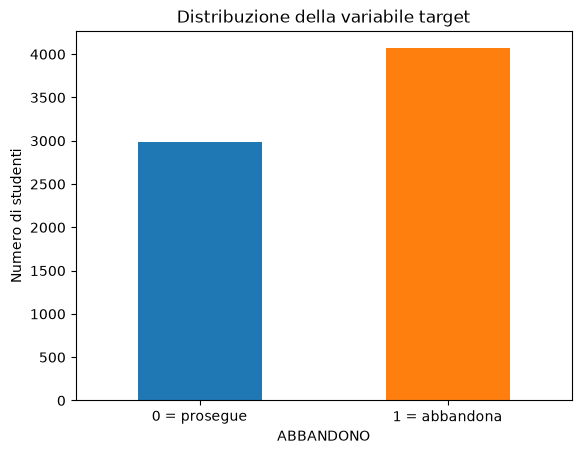

In [11]:
abbandono.value_counts().sort_index().plot(kind="bar", color=["tab:blue", "tab:orange"])
plt.title("Distribuzione della variabile target")
plt.xlabel("ABBANDONO")
plt.ylabel("Numero di studenti")
plt.xticks([0, 1], ["0 = prosegue", "1 = abbandona"], rotation=0)
plt.show()

**Il numeratore non cambia, il denominatore si'.** La prevalenza passa dallo 0,99% (su 411.749
azioni) al 57,7% (su 7.047 studenti). Le classi sono bilanciate: niente SMOTE, niente pesi di
classe.

## 4. Costruzione delle feature per studente

Escludiamo l'ultima azione di **ogni** studente, non solo dei positivi: altrimenti la regola
dipenderebbe dal target.

In [12]:
storia = dati.drop(index=ultime_azioni.index).copy()

print("azioni totali                     :", len(dati))
print("azioni usate per le feature       :", len(storia))
print("azioni minime per studente        :", storia.groupby("USERID").size().min())
print("studenti rimasti                  :", storia["USERID"].nunique())

azioni totali                     : 411749
azioni usate per le feature       : 404702
azioni minime per studente        : 4
studenti rimasti                  : 7047


In [13]:
# giorno solare della rilevazione a cui appartiene l'azione (i TIMESTAMP sono in secondi)
storia["GIORNO"] = (storia["TIMESTAMP"] // 86400).astype(int)

gruppi = storia.groupby("USERID")

# Un'unica passata per gruppo. Le quattro medie escono da una sola aggregazione su tutte
# e quattro le colonne insieme, non da un giro di ciclo per colonna: e' pandas a scorrere
# le 404.702 righe, in C, una volta sola.
studenti = pd.concat([
    pd.DataFrame({
        "n_azioni":            gruppi.size(),
        "n_attivita_distinte": gruppi["TARGETID"].nunique(),
        "n_giorni_attivi":     gruppi["GIORNO"].nunique(),
        "durata_giorni":       (gruppi["TIMESTAMP"].max() - gruppi["TIMESTAMP"].min()) / 86400,
    }),
    gruppi[COLONNE_FEATURE].mean().rename(columns=lambda c: c.lower() + "_media"),
], axis=1)

studenti["ABBANDONO"] = abbandono
studenti = studenti.round(3)

print(studenti.shape)
studenti.head(10)

(7047, 9)


,n_azioni,n_attivita_distinte,n_giorni_attivi,durata_giorni,feature0_media,feature1_media,feature2_media,feature3_media,ABBANDONO
USERID,,,,,,,,,
0,75,23,12,27.340,-0.320,-0.063,0.080,2.159,0
1,25,14,4,10.771,-0.320,-0.130,0.087,0.013,0
2,188,71,10,25.965,0.232,0.079,-0.066,-0.040,0
3,5,5,2,8.553,-0.320,0.073,0.007,-0.067,1
4,8,7,1,0.019,-0.320,0.200,0.295,0.861,1
5,87,44,10,25.054,0.114,-0.056,-0.008,0.080,0
6,29,11,6,16.830,0.005,-0.348,0.072,0.431,0
7,148,57,7,28.917,0.263,-0.436,0.019,0.014,0
8,8,5,2,1.013,-0.320,-0.436,0.107,-0.067,1


| feature | significato |
|---|---|
| `n_azioni` | quante azioni ha compiuto lo studente |
| `n_attivita_distinte` | su quante delle 97 attivita' del corso si e' mosso |
| `n_giorni_attivi` | in quanti giorni diversi si e' collegato |
| `durata_giorni` | quanti giorni separano la sua prima azione dall'ultima osservata |
| `feature0_media` … `feature3_media` | media delle quattro feature numeriche delle sue azioni |
| `ABBANDONO` | **target**: 1 se lo studente ha abbandonato |

`USERID` resta come indice per poter risalire allo studente, ma **non e' una feature**: e' un
identificativo, e nei task successivi le feature saranno `X = df.drop(columns="ABBANDONO")` sul
file letto con `index_col="USERID"`.

In [14]:
studenti.info()

<class 'pandas.DataFrame'>
Index: 7047 entries, 0 to 7046
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   n_azioni             7047 non-null   int64  
 1   n_attivita_distinte  7047 non-null   int64  
 2   n_giorni_attivi      7047 non-null   int64  
 3   durata_giorni        7047 non-null   float64
 4   feature0_media       7047 non-null   float64
 5   feature1_media       7047 non-null   float64
 6   feature2_media       7047 non-null   float64
 7   feature3_media       7047 non-null   float64
 8   ABBANDONO            7047 non-null   int64  
dtypes: float64(5), int64(4)
memory usage: 550.5 KB


In [15]:
print("valori mancanti :", studenti.isnull().sum().sum())
print("valori infiniti :", np.isinf(studenti.select_dtypes("number")).sum().sum())
print("righe duplicate :", studenti.duplicated().sum())
print("studenti attesi : 7047  ->  ottenuti:", len(studenti))
studenti.describe()

valori mancanti : 0
valori infiniti : 0
righe duplicate : 256
studenti attesi : 7047  ->  ottenuti: 7047


,n_azioni,n_attivita_distinte,n_giorni_attivi,durata_giorni,feature0_media,feature1_media,feature2_media,feature3_media,ABBANDONO
count,7047.000000,7047.000000,7047.000000,7047.000000,7047.000000,7047.000000,7047.000000,7047.000000,7047.000000
mean,57.428977,24.841919,4.497659,10.858370,-0.091233,-0.054136,0.022720,-0.001645,0.576983
std,57.838515,20.527060,3.713209,9.796875,0.259770,0.299919,0.293284,0.212772,0.494073
min,4.000000,1.000000,1.000000,0.000000,-0.320000,-0.436000,-0.269000,-0.067000,0.000000
25%,12.000000,7.000000,2.000000,0.393500,-0.320000,-0.365000,-0.051000,-0.067000,0.000000
50%,37.000000,18.000000,3.000000,9.035000,-0.155000,-0.030000,0.003000,-0.042000,1.000000
75%,86.000000,39.000000,6.000000,20.074500,0.048000,0.200000,0.072000,-0.000000,1.000000
max,504.000000,95.000000,25.000000,29.135000,3.384000,0.837000,20.488000,7.559000,1.000000


7.047 × 9, tutte numeriche, 0 mancanti, 0 infiniti. Le 256 righe duplicate sono studenti diversi
(`USERID` e' unico) con lo stesso profilo: pochissime azioni in un giorno solo. Restano.

## 5. Estrazione di `manuale.csv`

6 abbandoni e 6 non-abbandoni estratti a caso con `random_state=42`. Bilanciati per avere entropia
iniziale di 1 bit esatto nel Task 2.

In [16]:
positivi = studenti[studenti["ABBANDONO"] == 1]
negativi = studenti[studenti["ABBANDONO"] == 0]

manuale = pd.concat([
    positivi.sample(n=6, random_state=SEME),
    negativi.sample(n=6, random_state=SEME),
])
manuale = manuale.sample(frac=1, random_state=SEME)   # mescolati, per non avere le classi in blocco

print(manuale.shape)
manuale

(12, 9)


,n_azioni,n_attivita_distinte,n_giorni_attivi,durata_giorni,feature0_media,feature1_media,feature2_media,feature3_media,ABBANDONO
USERID,,,,,,,,,
3969,44,26,5,4.941,-0.167,0.258,-0.053,-0.013,0
635,138,73,7,26.158,0.081,0.228,-0.093,-0.044,0
4344,5,3,1,0.000,-0.320,-0.436,0.107,-0.067,1
1714,97,40,11,27.117,0.014,-0.200,-0.012,-0.057,0
1123,8,5,1,0.013,-0.320,-0.118,0.044,-0.067,1
3637,6,5,1,0.082,-0.320,-0.012,0.023,-0.067,1
4413,94,19,5,5.156,-0.191,-0.409,0.096,-0.031,1
2535,65,42,6,25.987,1.215,-0.436,0.045,0.831,0
4200,7,5,2,3.618,-0.320,0.291,0.035,-0.067,1


## 6. Estrazione di `training.csv`

Tutti gli altri 7.035. I 12 di `manuale.csv` sono esclusi: verranno usati per costruire a mano i
classificatori del Task 2.

In [17]:
training = studenti.drop(index=manuale.index)

print("training:", training.shape)
print()
print("distribuzione del target (%):")
print((training["ABBANDONO"].value_counts(normalize=True) * 100).round(2))
print()
print("nessuno studente in comune con manuale.csv:", training.index.intersection(manuale.index).empty)
print("manuale + training = tutti gli studenti   :", len(training) + len(manuale) == len(studenti))

training: (7035, 9)

distribuzione del target (%):
ABBANDONO
1    57.71
0    42.29
Name: proportion, dtype: float64

nessuno studente in comune con manuale.csv: True
manuale + training = tutti gli studenti   : True


## 7. Salvataggio

In [18]:
manuale.to_csv("../data/manuale.csv")     # USERID e' l'indice, quindi va salvato
training.to_csv("../data/training.csv")

# rilettura di controllo: i file devono tornare identici a quanto salvato
controllo = pd.read_csv("../data/training.csv", index_col="USERID")
print("training.csv riletto:", controllo.shape)
print("colonne:", list(controllo.columns))
print("uguale alla tabella in memoria:", controllo.equals(training))

training.csv riletto: (7035, 9)
colonne: ['n_azioni', 'n_attivita_distinte', 'n_giorni_attivi', 'durata_giorni', 'feature0_media', 'feature1_media', 'feature2_media', 'feature3_media', 'ABBANDONO']
uguale alla tabella in memoria: True


## 8. Verifica di sanita'

Una regressione logistica di default: serve solo a controllare che il segnale ci sia.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X = training.drop(columns="ABBANDONO")
y = training["ABBANDONO"]

# lo scaling sta dentro la Pipeline, cosi' viene stimato solo sulle pieghe di addestramento
modello = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

auc = cross_val_score(modello, X, y, cv=5, scoring="roc_auc").mean()
acc = cross_val_score(modello, X, y, cv=5, scoring="accuracy").mean()

print(f"regressione logistica, 5 pieghe:   AUC = {auc:.3f}   accuratezza = {acc:.3f}")
print(f"riferimento (predire sempre 1) :   accuratezza = {y.mean():.3f}")

regressione logistica, 5 pieghe:   AUC = 0.877   accuratezza = 0.797
riferimento (predire sempre 1) :   accuratezza = 0.577


AUC 0,877. **Ma la regola «poche azioni → abbandono» e' in parte tautologica**: un abbandono e' per
definizione la fine dell'attivita'. L'appendice qui sotto misura quanto pesa.

## 9. Appendice — la stessa cosa su una finestra iniziale

Rifacciamo il conto sulle prime *k* azioni di ogni studente, invece che sull'intera storia.

In [20]:
def profilo(sub):                                  # le stesse 8 feature, su una finestra iniziale
    g = sub.assign(GIORNO=sub["TIMESTAMP"] // 86400).groupby("USERID")
    return pd.concat([
        pd.DataFrame({"n_azioni": g.size(), "n_attivita_distinte": g["TARGETID"].nunique(),
                      "n_giorni_attivi": g["GIORNO"].nunique(),
                      "durata_giorni": (g["TIMESTAMP"].max() - g["TIMESTAMP"].min()) / 86400}),
        g[COLONNE_FEATURE].mean().rename(columns=lambda c: c.lower() + "_media"),
    ], axis=1)

for k in (4, 10):                                  # due finestre: ogni giro riaddestra il modello
    tenuti = storia.groupby("USERID").size().pipe(lambda s: s[s >= k]).index
    W, yk  = profilo(storia[storia["USERID"].isin(tenuti)].groupby("USERID").head(k)), abbandono.loc[tenuti]
    print(f"prime {k:2d} azioni: {len(W)} studenti (esclusi {len(abbandono) - len(W)}), positivi {yk.mean():.1%}, AUC {cross_val_score(modello, W, yk, cv=5, scoring='roc_auc').mean():.3f}")

prime  4 azioni: 7047 studenti (esclusi 0), positivi 57.7%, AUC 0.535


prime 10 azioni: 5670 studenti (esclusi 1377), positivi 49.2%, AUC 0.542


AUC **0,535** contro 0,877. Il modello sull'intera storia misura in gran parte il fatto contabile
che chi abbandona ha fatto meno cose.

## 10. Il preprocessing come modulo

Le otto feature sono definite da noi e non esistono nel dataset originale, quindi un file d'esame va
trasformato prima di darlo al modello. `costruisci_studenti` riconosce il formato: trasforma un log
di azioni, restituisce invariata una tabella gia' a livello studente, tollera l'assenza di `LABEL`.

La cella seguente verifica che il modulo produca **esattamente** la tabella costruita qui sopra.

In [21]:
import preprocessing as pp

dal_modulo = pp.costruisci_studenti(pp.carica_azioni())
print("il modulo riproduce la tabella del notebook:", dal_modulo.equals(studenti))
print("il modulo riproduce training.csv           :", dal_modulo.drop(index=manuale.index).equals(training))

# come si usera' all'esame: due righe, qualunque sia il formato del file ricevuto
X_esame, y_esame = pp.carica_per_predire("../data/training.csv")   # segnaposto per real_settings.csv
print("X_esame:", X_esame.shape, " colonne attese:", list(X_esame.columns) == list(X.columns))

il modulo riproduce la tabella del notebook: True
il modulo riproduce training.csv           : True
X_esame: (7035, 8)  colonne attese: True


## 11. Appendice — i conti citati nella documentazione

Quattro numeri che la documentazione riporta senza mostrarli: la degenerazione del problema a
livello azione e le tre feature di intervallo scartate al punto 4.

In [22]:
# 1. a livello azione il problema e' quasi degenere
ultima   = dati.index.isin(ultime_azioni.index).astype(int)
etichetta = dati["LABEL"].to_numpy()
print(f"rispondere sempre 0    : accuratezza {(etichetta == 0).mean():.4f}")
print(f"regola \"e' l'ultima?\"  : accuratezza {(ultima == etichetta).mean():.4f}   "
      f"richiamo {(ultima[etichetta == 1] == 1).mean():.3f}")

# 2-3. le feature di intervallo fra azioni consecutive, scartate
g = storia.groupby("USERID")
intervalli = g["TIMESTAMP"].diff()
medio_ore  = intervalli.groupby(storia["USERID"]).mean() / 3600
mediano_s  = intervalli.groupby(storia["USERID"]).median()
atteso     = (g["TIMESTAMP"].max() - g["TIMESTAMP"].min()) / 3600 / (g.size() - 1)
print(f"\nintervallo_medio_ore == durata/(n_azioni-1)  : {np.allclose(medio_ore, atteso)}  -> ridondante")
print(f"intervallo_mediano: mediana {mediano_s.median():.1f} s "
      f"(quartili {mediano_s.quantile(.25):.1f} e {mediano_s.quantile(.75):.1f})")
print(f"   da sola, AUC in 5 pieghe: "
      f"{cross_val_score(modello, mediano_s.to_frame(), abbandono, cv=5, scoring='roc_auc').mean():.3f}")

# 4. somma invece di media delle FEATURE: resta ridondante.
# `corrwith` allinea le due tabelle per nome di colonna e restituisce le quattro
# correlazioni in un colpo solo.
correlazioni = g[COLONNE_FEATURE].sum().corrwith(g[COLONNE_FEATURE].mean())
print("\ncorrelazione fra somma e media di ciascuna FEATURE:")
print(correlazioni.round(2).to_string())

rispondere sempre 0    : accuratezza 0.9901
regola "e' l'ultima?"  : accuratezza 0.9928   richiamo 1.000

intervallo_medio_ore == durata/(n_azioni-1)  : True  -> ridondante
intervallo_mediano: mediana 22.0 s (quartili 12.5 e 51.5)


   da sola, AUC in 5 pieghe: 0.496

correlazione fra somma e media di ciascuna FEATURE:
FEATURE0    0.69
FEATURE1    0.68
FEATURE2    0.91
FEATURE3    0.66


## Riepilogo del Task 1

| passo | risultato |
|---|---|
| unione dei tre file | 411.749 × 9, per posizione |
| controllo qualita' | 0 mancanti, 0 duplicati, 0 valori fuori range |
| cambio di unita' di analisi | da 411.749 azioni a 7.047 studenti |
| target | `ABBANDONO`, 57,7% di positivi (era 0,99% a livello azione) |
| feature | 8 per studente, escludendo l'ultima azione di ognuno |
| `manuale.csv` / `training.csv` | 12 (6+6) / 7.035 |